This notebook produces panels a and b of Figure 18, which is a zoomed-in region within Focus Area A where the Spreckels sugar factory is located. There are particularly pronounced average coherence differences between methods 1 and 2 where the retention ponds are located.
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel.
***

In [ ]:
#import necessary packages
from osgeo import gdal
import numpy as np
import matplotlib.pyplot as plt
%matplotlib  widget

In [3]:
# load average coherence (average gamma1 and average gamma2)
saveDir_avg = '../../2_Calculating_coherence_2_ways/'

fileNameAvg_1 = 'avg_coh_method1.r4'  
f1 = gdal.Open(saveDir_avg + fileNameAvg_1, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m1 = f1.ReadAsArray()
f1 = None

fileNameAvg_2 = 'avg_coh_method2.r4'  
f2 = gdal.Open(saveDir_avg + fileNameAvg_2, gdal.GA_ReadOnly)  #check correct directory
coh_avg_m2 = f2.ReadAsArray()
f2 = None

In [7]:
# define the focus area of interest
imperial_road = [6820, 100, 7520, 450]

# need the width and height to calculate the proper visual aspect ratio 
dx= 9000; dy=1575
aspect_rat = (21.8/dy) / (34.44/dx)

In [5]:
# define a function for adding colorbar to avg coherence images
def add_colorbar(fig, ax, im, side="left", width=0.025, pad=0.00, height=0.2, label=None, visible=True):
    pos = ax.get_position()
    y0 = pos.y0 + (pos.height - height) / 2
    if side == "left":
        cax = fig.add_axes([
            pos.x0 - pad - width,
            y0,
            width,
            height
        ])
        orientation = "vertical"
        tick_side = "left"
        label_side = "left"
    else:
        cax = fig.add_axes([
            pos.x1 + pad,
            y0,
            width,
            height
        ])
        orientation = "vertical"
        tick_side = "right"
        label_side = "right"
    cbar = fig.colorbar(im, cax=cax, orientation=orientation)
    # ---- THIS is the important part ----
    if side == "left":
        cbar.ax.yaxis.set_ticks_position('left')
        cbar.ax.yaxis.set_label_position('left')
    else:
        cbar.ax.yaxis.set_ticks_position('right')
        cbar.ax.yaxis.set_label_position('right')
    if label:
        cbar.set_label(label)

    if visible==False:
        cbar.ax.set_visible(False)
    return cbar

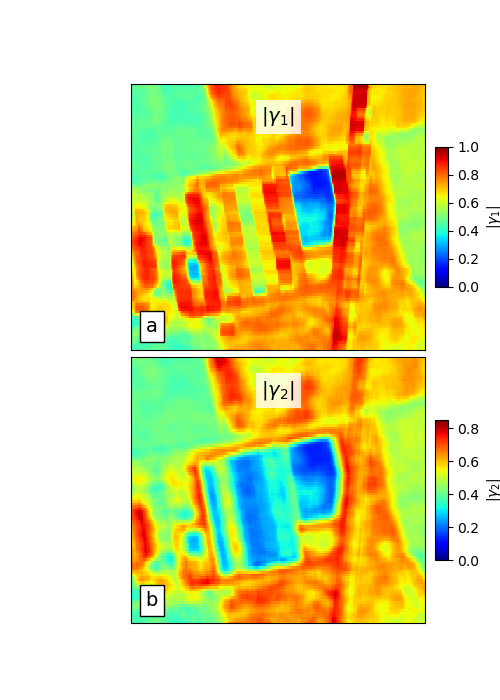

In [ ]:
# This is panels a and b of Figure 18.
zoom_in = imperial_road
loc_of_xy_center = (6880+7300)/2

label_x = 0.09
label_y = 0.05
props = dict(boxstyle='square',facecolor='white',edgecolor='black')
frac = 0.025

fig, axs = plt.subplots(2,1,figsize=(5,7)) # figsize just has to be big enough to accomodate the aspect ratio!!!
plt.subplots_adjust(wspace=0.05,hspace=0.03,left=0.15,right=0.85)

ax = axs[0]
im = ax.imshow(np.fliplr(coh_avg_m1),interpolation ='none',cmap='jet',vmin=0,vmax=1)
ax.set_anchor('E')
ax.set_aspect(aspect_rat)
add_colorbar(fig,ax,im,side='right',pad=0.02,label='$|\\gamma_{1}|$')
ax.set_xlim(6880, 7300)
ax.set_ylim(380, 275)
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'a', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,275+15,'|$\gamma_{1}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

ax = axs[1]
im = ax.imshow(np.fliplr(coh_avg_m2),interpolation ='none',cmap='jet',vmin=0,vmax=0.85)
ax.set_aspect(aspect_rat)
ax.set_anchor('E')
add_colorbar(fig,ax,im,side='right',pad=0.02,label='$|\\gamma_{2}|$')
ax.set_xlim(6880, 7300)
ax.set_ylim(380, 275)
ax.set_xticks([]); ax.set_yticks([])
ax.text(label_x, label_y, 'b', bbox=props, fontsize=14,
        ha='right', va='bottom', transform=ax.transAxes)
ax.text(loc_of_xy_center,275+15,'|$\gamma_{2}|$',fontsize=14,ha='center',bbox=dict(facecolor='white',edgecolor='none',alpha=0.8))

plt.show()
#plt.savefig('focus_area_A_zoomed_in.png', transparent=True, bbox_inches='tight',dpi=500)

Panel c of Figure 18 comes from Waring, 2023 (found here: https://www.google.com/search?q=WASTE+DISCHARGE+REQUIREMENTS+ORDER+R7-2023-0001+i+SPRECKELS+SUGAR+COMPANY%2C+INC.+SUGAR+BEET+PROCESSING+FACILITY%2C+BRAWLEY+IMPERIAL+COUNTY&oq=WASTE+DISCHARGE+REQUIREMENTS+ORDER+R7-2023-0001+i+SPRECKELS+SUGAR+COMPANY%2C+INC.+SUGAR+BEET+PROCESSING+FACILITY%2C+BRAWLEY+IMPERIAL+COUNTY&gs_lcrp=EgZjaHJvbWUyBggAEEUYOdIBBzY0NGowajSoAgCwAgE&sourceid=chrome&source=chrome.ob&ie=UTF-8#:~:text=Web%20results-,Waste%20Discharge%20Requirements%20Order%20R7%2D2023%2D0001,https%3A//www.waterboards.ca.gov%20%E2%80%BA%20resolutions%20%E2%80%BA%20fi...,-PDF) <br>
Or search for "WASTE DISCHARGE REQUIREMENTS ORDER R7-2023-0001 i SPRECKELS SUGAR COMPANY, INC. SUGAR BEET PROCESSING FACILITY, BRAWLEY IMPERIAL COUNTY" which will result in the PDF as the first hit on Google.
<br>
Panel d of Figure 18 is from Google Earth.